In [17]:
import time 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [18]:
print ("Loading MNIST dataset......")
x,y = fetch_openml('mnist_784',
                   version=1,
                   return_X_y=True, 
                   as_frame = False)
x = x.astype('float32')
y = y.astype('int')
print("Dataset loaded Successfully !")
print ("total samples :",x.shape[0])
print("Number of features:",x.shape[1])

Loading MNIST dataset......
Dataset loaded Successfully !
total samples : 70000
Number of features: 784


In [19]:
x = x/255.0
x= x[:20000]
y= y[:20000]
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    train_size=0.2,
    stratify=y,
    random_state=42
)
print("\nTraining Samples:", x_train.shape[0])
print("\nTesting Samples:", x_test.shape[0])



Training Samples: 4000

Testing Samples: 16000


In [22]:
activations =['logistic', 'relu' , 'tanh']
results = {}
training_times = {}
accuracies = {}

In [27]:
for activation in activations:
    print("\n" + "-" * 30)
    print("\nTraining with:", activation)
    print("\n" + "-" * 30)

    start_time = time.time()

    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=activation,
        solver='adam',
        max_iter=100,
        batch_size=128,
        random_state=42,
        verbose=False
    )

    model.fit(x_train, y_train)

    end_time = time.time()
    training_time = end_time - start_time
    y_pred =model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)

    results[activation] = model
    training_times[activation] = training_time

    accuracies[activation] = accuracy *100
  
    print("Training time : {:.2f}seconds".format(training_time))
    print("Number of iterations:",model.n_iter_)
    print("Test Accuracy : {:.2f}%".format(accuracy*100))
    


------------------------------

Training with: logistic

------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Training time : 29.01seconds
Number of iterations: 100
Test Accuracy : 92.58%

------------------------------

Training with: relu

------------------------------
Training time : 24.17seconds
Number of iterations: 83
Test Accuracy : 93.42%

------------------------------

Training with: tanh

------------------------------
Training time : 24.98seconds
Number of iterations: 93
Test Accuracy : 92.59%


In [31]:
print("\n" + "=" * 30)
print("ACTIVATION FUNCTION COMPARISON")
print("=" * 30)

print("{:<12} {:<15} {:<15} {:<15}".format(
    "Activation", "Time (sec)", "Iterations", "Accuracy (%)"
))

for activation in activations:
    model = results[activation]

    print("{:<12} {:<15.2f} {:<15} {:<15.2f}".format(
        activation,
        training_times[activation],
        model.n_iter_,
        accuracies[activation]
    ))


ACTIVATION FUNCTION COMPARISON
Activation   Time (sec)      Iterations      Accuracy (%)   
logistic     29.01           100             92.58          
relu         24.17           83              93.42          
tanh         24.98           93              92.59          


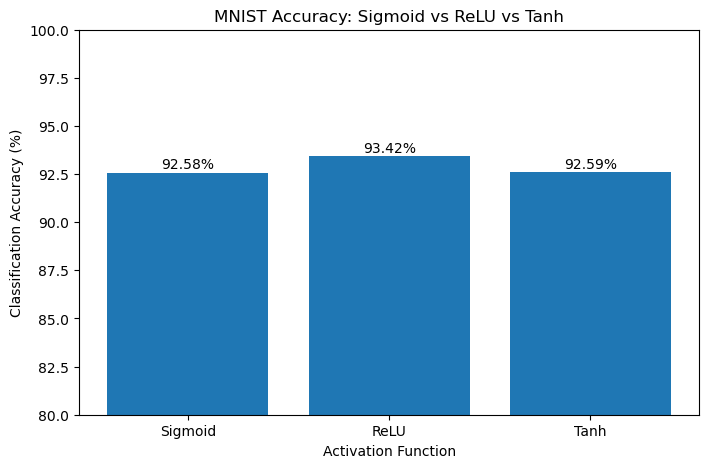

In [30]:

accuracy_values = [
    accuracies['logistic'],
    accuracies['relu'],
    accuracies['tanh']
]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Sigmoid', 'ReLU', 'Tanh'],
    accuracy_values
)

plt.xlabel("Activation Function")
plt.ylabel("Classification Accuracy (%)")
plt.title("MNIST Accuracy: Sigmoid vs ReLU vs Tanh")
plt.ylim(80, 100)

for i, value in enumerate(accuracy_values):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha='center'
    )

plt.show()

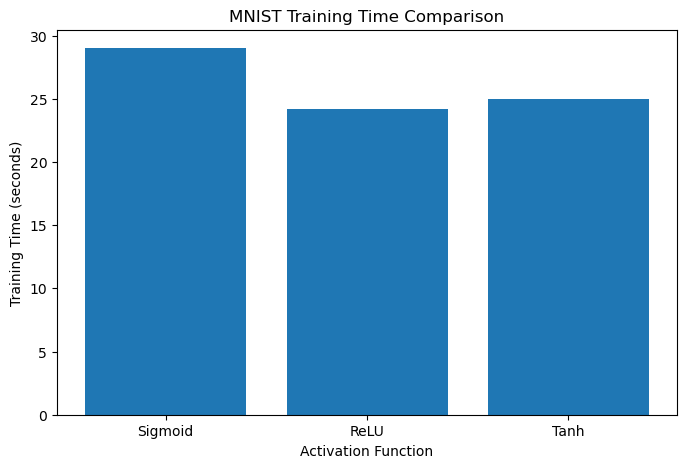

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    ['Sigmoid', 'ReLU', 'Tanh'],
    [
        training_times['logistic'],
        training_times['relu'],
        training_times['tanh']
    ]
)

plt.xlabel("Activation Function")
plt.ylabel("Training Time (seconds)")
plt.title("MNIST Training Time Comparison")


plt.show()

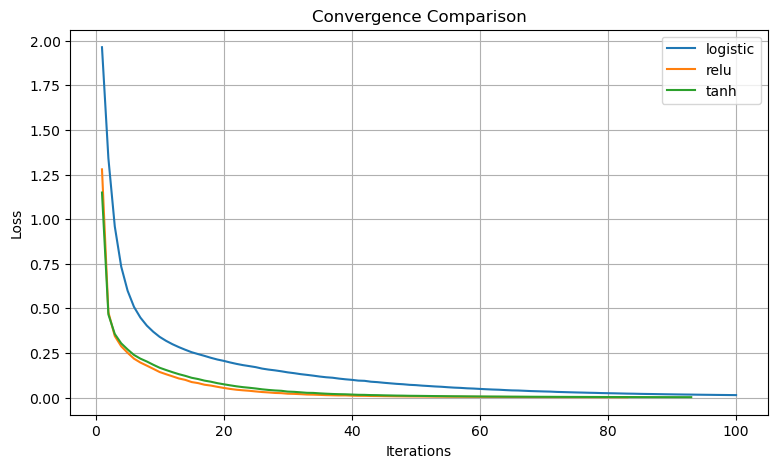

In [33]:
plt.figure(figsize=(9, 5))

for activation in activations:
    model = results[activation]

    plt.plot(
        range(1, len(model.loss_curve_) + 1),
        model.loss_curve_,
        label=activation
    )

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()